In [2]:
import pandas as pd

# load the dataset
df = pd.read_csv("data.csv")

# look at the first few rows
df.head()


,0.78051,-0.063669,1
0,0.28774,0.29139,1
1,0.40714,0.17878,1
2,0.29230,0.42170,1
3,0.50922,0.35256,1
4,0.27785,0.10802,1


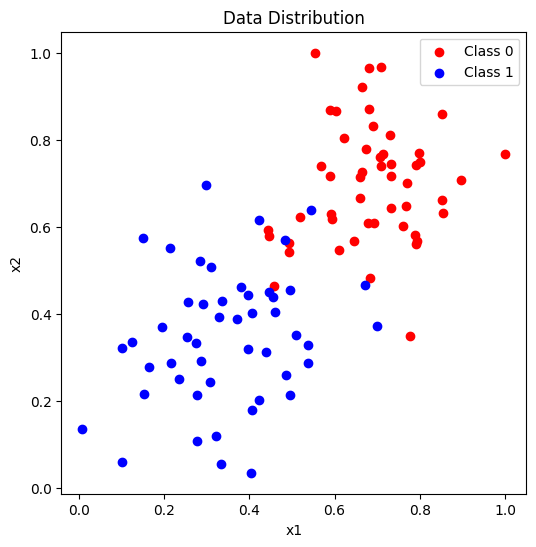

In [27]:
import matplotlib.pyplot as plt

# Assign columns 
df.columns = ['x1', 'x2', 'y']

# Separate the two classes
class0 = df[df['y'] == 0]
class1 = df[df['y'] == 1]

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(class0['x1'], class0['x2'], color='red', label='Class 0')
plt.scatter(class1['x1'], class1['x2'], color='blue', label='Class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Data Distribution')
plt.legend()
plt.show()


In [28]:
import numpy as np

# Convert the data to numpy arrays
X = df[['x1', 'x2']].values
y = df['y'].values

# Initialize weights and bias randomly
np.random.seed(42)
w = np.random.rand(2)
b = np.random.rand(1)
learning_rate = 0.1

# Function for the step activation
def step_function(z):
    return 1 if z >= 0 else 0

# Function to predict output
def predict(x):
    z = np.dot(w, x) + b
    return step_function(z)

# Training loop
for epoch in range(10):  
    for i in range(len(X)):
        y_hat = predict(X[i])
        error = y[i] - y_hat
        w = w + learning_rate * error * X[i]
        b = b + learning_rate * error

print("Final weights:", w)
print("Final bias:", b)


Final weights: [-0.24672088 -0.29606129]
Final bias: [0.13199394]


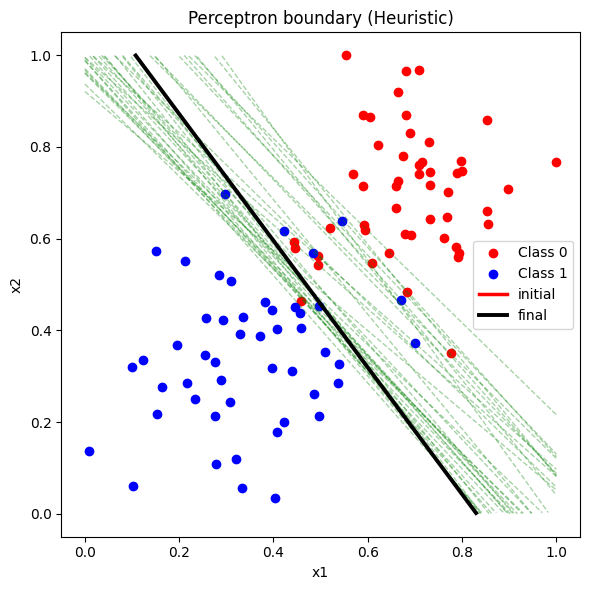

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Data
df.columns = ['x1','x2','y']
X = df[['x1','x2']].values.astype(float)
y = df['y'].values.astype(int)

# Heuristic perceptron
np.random.seed(7)
w = np.random.rand(2)
b = float(np.random.rand())
lr = 0.9
epochs = 65

def step_fn(z): 
    return 1 if z >= 0 else 0

history_h = [(w.copy(), b)]  # store once per epoch

for _ in range(epochs):
    idx = np.random.permutation(len(X))
    for i in idx:
        z = X[i] @ w + b
        yhat = step_fn(z)
        err = y[i] - yhat
        w += lr * err * X[i]
        b += lr * err
    history_h.append((w.copy(), b))

# Plot heur. boundary
def plot_boundary(w, b, **kw):
    xs = np.linspace(0, 1, 400)
    ys = -(w[0]*xs + b) / (w[1] + 1e-12)
    mask = (ys >= 0) & (ys <= 1)
    plt.plot(xs[mask], ys[mask], **kw)

class0 = X[y==0]; class1 = X[y==1]
plt.figure(figsize=(6,6))
plt.scatter(class0[:,0], class0[:,1], c='red', label='Class 0')
plt.scatter(class1[:,0], class1[:,1], c='blue', label='Class 1')

plot_boundary(history_h[0][0], history_h[0][1], color='red', linewidth=2.5, label='initial')
for wi, bi in history_h[1:-1:2]:
    plot_boundary(wi, bi, color='green', linestyle='--', linewidth=1.0, alpha=0.35)
plot_boundary(history_h[-1][0], history_h[-1][1], color='black', linewidth=2.8, label='final')

plt.title("Perceptron boundary (Heuristic)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.legend()
plt.tight_layout()
plt.savefig("part1_boundary.png", dpi=200)
plt.show()


Final weights: [-1.73383728 -1.83252723]
Final bias: 1.680069656478836


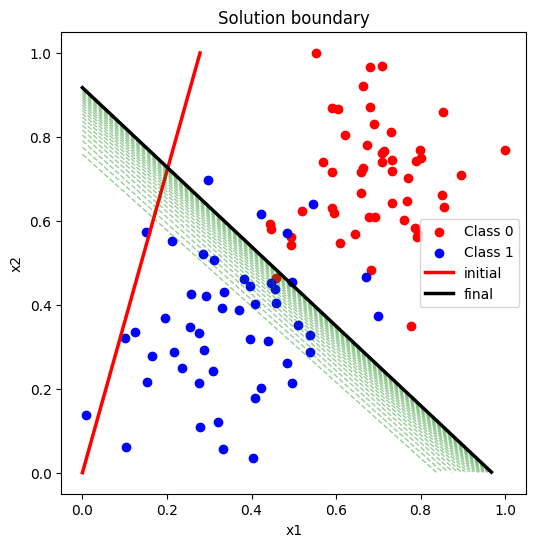

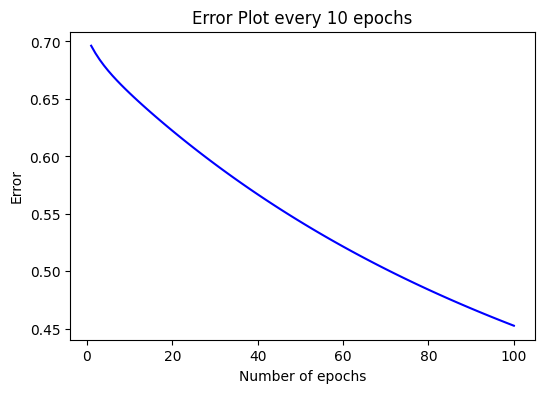

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Data prep
df.columns = ['x1','x2','y']
X = df[['x1','x2']].values.astype(float)
y = df['y'].values.astype(float)

# Sigmoid and log loss
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

def log_loss(y_true, y_pred, eps=1e-9):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true*np.log(y_pred) + (1 - y_true)*np.log(1 - y_pred))

# Initialize parameters
np.random.seed(42)
w = np.random.randn(2) * 0.1
b = 0.0
lr = 0.4
epochs = 100

# Training loop
m = len(X)
history = [(w.copy(), b)]
losses = []

for epoch in range(epochs):
    z = X @ w + b
    yhat = sigmoid(z)
    
    # compute loss and gradients
    loss = log_loss(y, yhat)
    
    grad_w = (X.T @ (yhat - y)) / m
    grad_b = np.mean(yhat - y)
    w -= lr * grad_w
    b -= lr * grad_b
    
    history.append((w.copy(), b))
    losses.append(loss)

print("Final weights:", w)
print("Final bias:", b)

# Helper to plot boundary
def plot_boundary(w, b, **kw):
    w1, w2 = w
    xs = np.linspace(0, 1, 400)
    ys = -(w1 * xs + b) / w2
    mask = (ys >= 0) & (ys <= 1)
    plt.plot(xs[mask], ys[mask], **kw)

# ========= PLOT 1: Solution Boundary =========
plt.figure(figsize=(6,6))
class0 = df[df['y']==0].values
class1 = df[df['y']==1].values

plt.scatter(class0[:,0], class0[:,1], c='red', label='Class 0')
plt.scatter(class1[:,0], class1[:,1], c='blue', label='Class 1')

# Plot initial, intermediate, and final lines
plot_boundary(history[0][0], history[0][1], color='red', linewidth=2.5, label='initial')
for (wi, bi) in history[-60::3]:  # only last 60 epochs, every 3rd, to look smooth
    plot_boundary(wi, bi, color='green', linestyle='--', linewidth=1.0, alpha=0.4)
plot_boundary(history[-1][0], history[-1][1], color='black', linewidth=2.5, label='final')

plt.title("Solution boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

# ========= PLOT 2: Error Plot =========
plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), losses, color='blue')
plt.title("Error Plot every 10 epochs")
plt.xlabel("Number of epochs")
plt.ylabel("Error")
plt.show()
